<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_1_B_Train_Test_Split_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque B: La Regla de Oro del Machine Learning
**Sprint 2.1 - Metodología del Machine Learning**

En el bloque anterior aprendiste a entrenar un modelo (`.fit`). Pero, ¿qué pasa si le preguntas por los mismos datos con los que estudió? ¡Acierta siempre!

### 🎯 Objetivos:
1.  **Overfitting:** Entender por qué un 100% de acierto es un desastre.
2.  **Split:** Implementar la división de datos (Train/Test) para simular el mundo real.
3.  **Reproducibilidad:** Usar `random_state` para resultados consistentes.

## 1. El Peligro del 100% (Overfitting)

Si un modelo acierta perfectamente en los datos que usó para estudiar (Train Set), pero falla con datos nuevos, decimos que hay **Overfitting** (Sobreajuste).

*   **El Modelo:** Es como un estudiante que **memorizó** las preguntas del examen, pero no aprendió el concepto subyacente.
*   **La Consecuencia:** En producción (mundo real), el modelo es inútil y genera pérdidas de dinero.

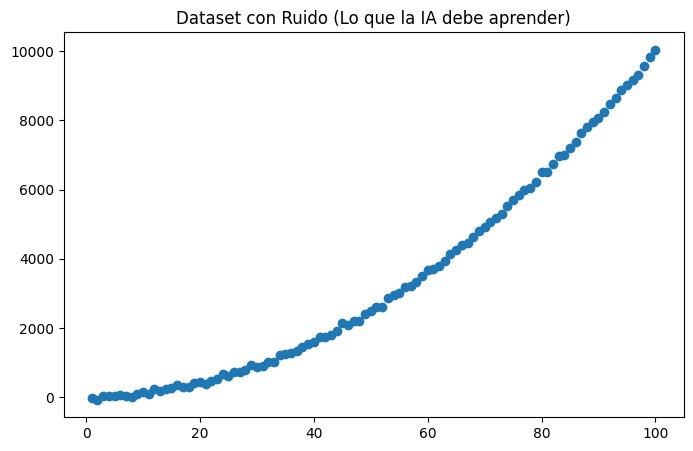

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generamos 100 datos ficticios para simular una distribución
# X: Valores de la 1 a la 100
X = np.arange(1, 101).reshape(-1, 1)
# y: Un patrón simple + algo de ruido
y = X**2 + np.random.normal(0, 50, 100).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.title("Dataset con Ruido (Lo que la IA debe aprender)")
plt.show()

## 2. La División Mágica (Train / Test Split)

La solución es simple: **esconde una parte de los datos ($X_{test}$ y $y_{test}$) y no se la enseñes al modelo hasta el final.**

*   **Train Set (80%):** Datos para el estudio.
*   **Test Set (20%):** Datos para el examen final (la prueba de fuego).

Total datos: 100
Para entrenar (80%): 80
Para el examen (20%): 20


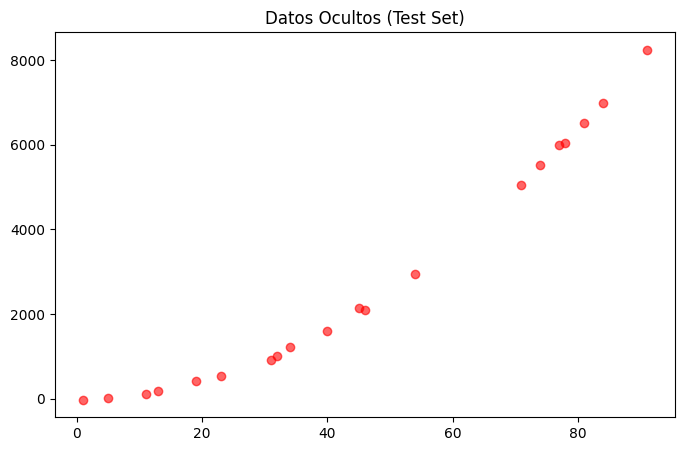

In [2]:
# 1. IMPORTAR LA HERRAMIENTA
# Ya importamos train_test_split en la primera celda.

# 2. DEFINICIÓN DE TAMAÑOS
# test_size=0.2  -> Reserva el 20% para el examen.
# random_state=42 -> Fija la semilla para que la división sea siempre la misma.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # TODO: Pon el 20%
    random_state=42 # TODO: Pon el 42 (la semilla)
)

print(f"Total datos: {len(X)}")
print(f"Para entrenar (80%): {len(X_train)}")
print(f"Para el examen (20%): {len(X_test)}")

# VISUALIZACIÓN DE LOS TEST DATA (Datos ocultos a la IA)
# Estos puntos son los que pondrán a prueba la capacidad de generalización.
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='red', alpha=0.6)
plt.title("Datos Ocultos (Test Set)")
plt.show()

## 3. Reproducibilidad (Random State)

Si no pones `random_state=42`, cada vez que ejecutes el código, los datos se mezclan de forma diferente.

*   **Consecuencia:** Tu modelo saca 80% hoy. Mañana ejecutas y saca 60%. ¿Qué pasó? No fue el modelo, fue la mezcla aleatoria de los datos.
*   **Solución:** Usar `random_state` garantiza que la mezcla sea la misma, haciendo que tus resultados sean **reproducibles** por ti o por un compañero.